## Importação das Bibliotecas

Nesta célula, importamos as bibliotecas necessárias para a análise de dados e visualização gráfica: Pandas e Matplotlib. Pandas é usado para manipulação e análise de dados, enquanto Matplotlib é usado para criar gráficos.


In [1]:
import pandas as pand
import matplotlib.pyplot as mp

## Leitura e Limpeza dos Dados

Aqui, lemos o arquivo CSV `googleplaystore.csv` e removemos linhas duplicadas. Em seguida, limpamos a coluna `Installs`, removendo caracteres não numéricos e convertendo os valores para inteiros. As primeiras linhas do dataset e os valores da coluna `Installs` após a limpeza são exibidos abaixo.


In [2]:
csv = pand.read_csv('googleplaystore.csv')
csv.drop_duplicates(inplace=True) 
print('Primeiras linhas do CSV: ')
print(csv.head())

csv['Installs'] = csv['Installs'].str.replace(',', '').str.replace('+', '')
csv['Installs'] = pand.to_numeric(csv['Installs'], errors='coerce')
csv = csv.dropna(subset=['Installs']) 
csv['Installs'] = csv['Installs'].astype(int) 

print('Valores de Installs após as limpezas: ')
print(csv['Installs'].head(10))

Primeiras linhas do CSV: 
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0  

## Top 5 Apps por Número de Instalações

Nesta célula, identificamos os 5 aplicativos mais instalados e criamos um gráfico de barras para visualizar esses dados.

Os top 5 Apps mais instalados: 
                                         App    Installs
152                        Google Play Books  1000000000
335  Messenger  Text and Video Chat for Free  1000000000
336                       WhatsApp Messenger  1000000000
338             Google Chrome: Fast & Secure  1000000000
340                                    Gmail  1000000000


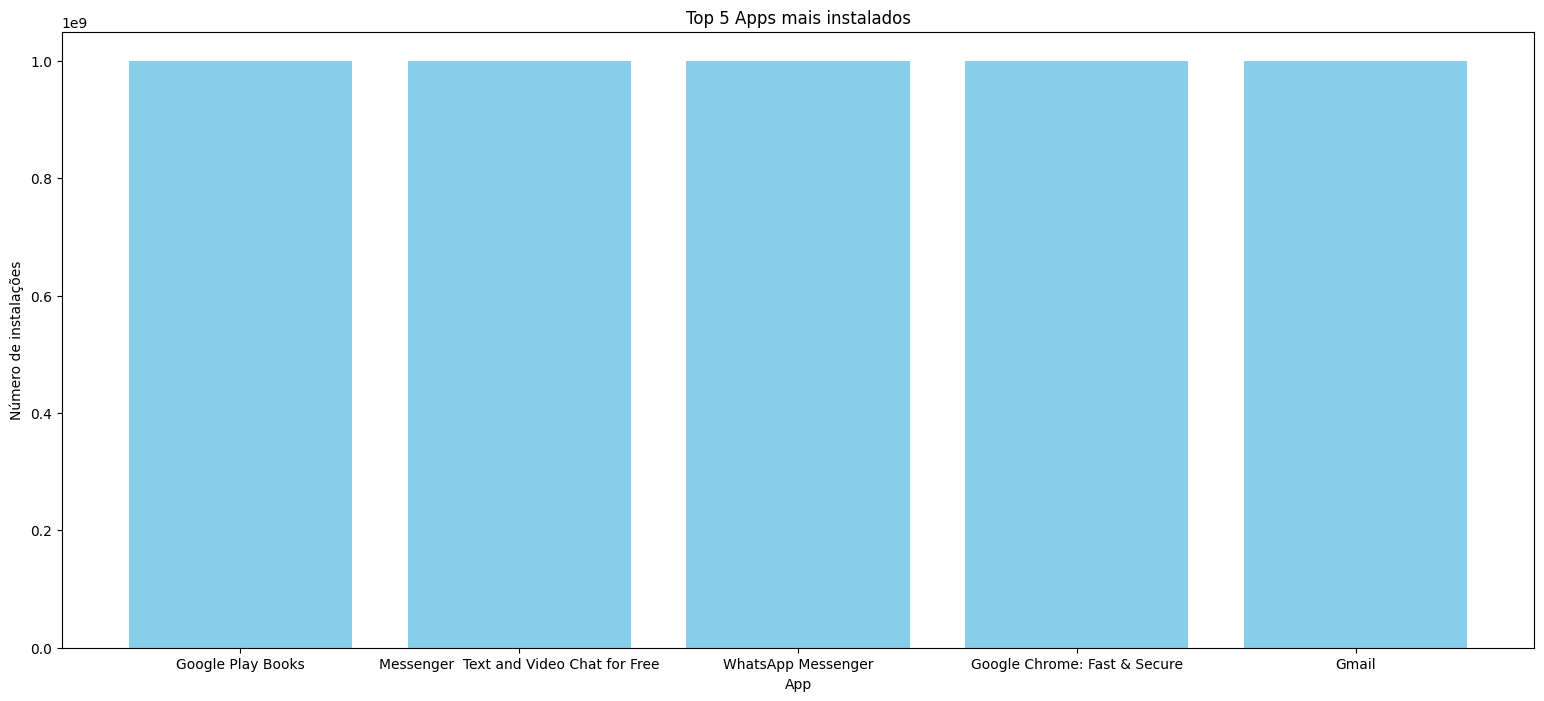

In [3]:
csv['App'] = csv['App'].str.replace(r'[^\x00-\x7F]+', '', regex=True)

top5 = csv.nlargest(5, 'Installs')
print("Os top 5 Apps mais instalados: ")
print(top5[['App', 'Installs']])

mp.figure(figsize=(19,8))
mp.bar(top5['App'], top5['Installs'], color='skyblue')
mp.xlabel('App')
mp.ylabel('Número de instalações')
mp.title('Top 5 Apps mais instalados')
mp.xticks(rotation=0, ha='center')
mp.show()

## Distribuição de Categorias dos Apps

Criamos um gráfico de pizza para mostrar a distribuição das diferentes categorias de aplicativos no dataset.


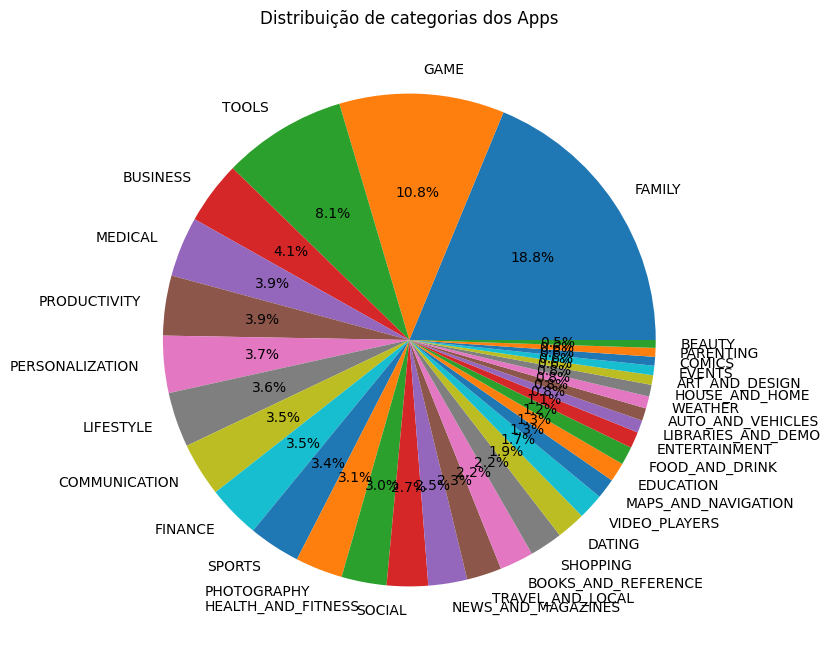

In [14]:
distrib_categoria = csv['Category'].value_counts()
mp.figure(figsize=(18, 8))
mp.pie(distrib_categoria, labels=distrib_categoria.index, autopct='%1.1f%%') 
mp.title('Distribuição de categorias dos Apps')
mp.show()

## App Mais Caro

Aqui, identificamos o aplicativo mais caro no dataset e exibimos seu nome e preço.


In [15]:
csv['Price'] = csv['Price'].str.replace('$', '').replace('Free', '0')
csv['Price'] = pand.to_numeric(csv['Price'], errors='coerce')
AppCaro = csv[csv['Price'] == csv['Price'].max()]
print("\nO aplicativo mais caro é:{} \nValor do aplicativo: R$ {}".format(AppCaro['App'].values[0], AppCaro['Price'].values[0]))


O aplicativo mais caro é:I'm Rich - Trump Edition 
Valor do aplicativo: R$ 400.0


## Contagem de Apps Classificados como 'Mature 17+'

Nesta célula, contamos o número total de aplicativos que têm a classificação 'Mature 17+'.


In [16]:
Appmais17 = csv[csv['Content Rating'] == 'Mature 17+'].shape[0]
print("\nO total de aplicativos com classificação para 'Mature 17+' é de: {}".format(Appmais17))


O total de aplicativos com classificação para 'Mature 17+' é de: 447


## Top 10 Apps por Número de Reviews

Identificamos os 10 aplicativos com o maior número de reviews e criamos um gráfico de barras para visualizá-los.

Top 10 Apps por número de reviews:
                                                    App     Reviews
2544                                           Facebook  78158306.0
336                                  WhatsApp Messenger  69119316.0
2545                                          Instagram  66577313.0
335             Messenger  Text and Video Chat for Free  56642847.0
1670                                     Clash of Clans  44891723.0
4005            Clean Master- Space Cleaner & Antivirus  42916526.0
1654                                     Subway Surfers  27722264.0
3665                                            YouTube  25655305.0
7536  Security Master - Antivirus, VPN, AppLock, Boo...  24900999.0
1660                                       Clash Royale  23133508.0


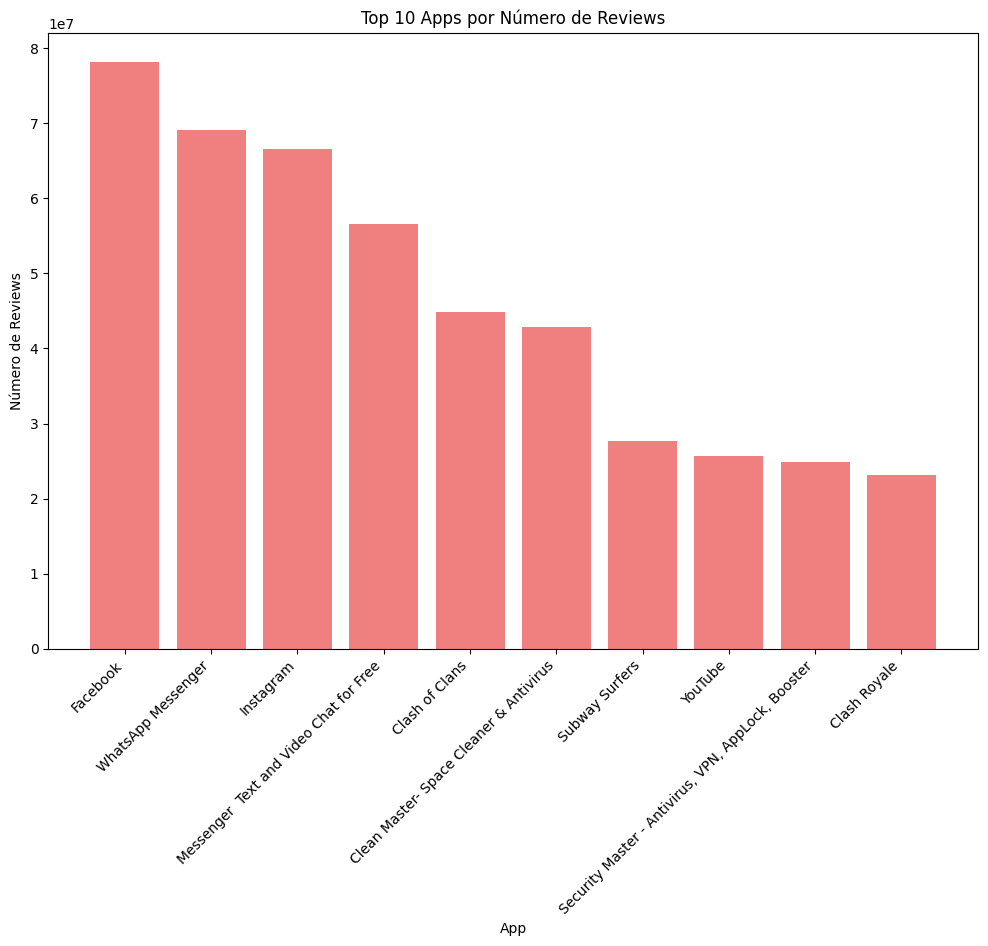

In [17]:
csv.drop_duplicates(inplace=True)
csv['Reviews'] = csv['Reviews'].astype(float)
csv_rmLinhadp = csv.drop_duplicates(subset=['App'])
top10 = csv_rmLinhadp.nlargest(10, 'Reviews')
print("Top 10 Apps por número de reviews:")
print(top10[['App', 'Reviews']])
mp.figure(figsize=(12,8))
mp.bar(top10['App'], top10['Reviews'], color='lightcoral')
mp.xlabel('App')
mp.ylabel('Número de Reviews')
mp.title('Top 10 Apps por Número de Reviews')
mp.xticks(rotation=45, ha='right')
mp.show()


## Média de Preço por Categoria

Calculamos a média de preço dos aplicativos para cada categoria e exibimos um gráfico de linha para visualizá-la.

Média de preço por categoria: Category
ART_AND_DESIGN         0.091846
AUTO_AND_VEHICLES      0.158471
BEAUTY                 0.000000
BOOKS_AND_REFERENCE    0.520739
BUSINESS               0.410515
COMICS                 0.000000
COMMUNICATION          0.227158
DATING                 0.160357
EDUCATION              0.138154
ENTERTAINMENT          0.071892
EVENTS                 1.718594
FAMILY                 1.245919
FINANCE                8.057861
FOOD_AND_DRINK         0.068387
GAME                   0.256289
HEALTH_AND_FITNESS     0.210294
HOUSE_AND_HOME         0.000000
LIBRARIES_AND_DEMO     0.011647
LIFESTYLE              6.329410
MAPS_AND_NAVIGATION    0.196715
MEDICAL                2.501691
NEWS_AND_MAGAZINES     0.015076
PARENTING              0.159667
PERSONALIZATION        0.390387
PHOTOGRAPHY            0.379596
PRODUCTIVITY           0.616536
SHOPPING               0.024464
SOCIAL                 0.057036
SPORTS                 0.284900
TOOLS                  0.317023
T

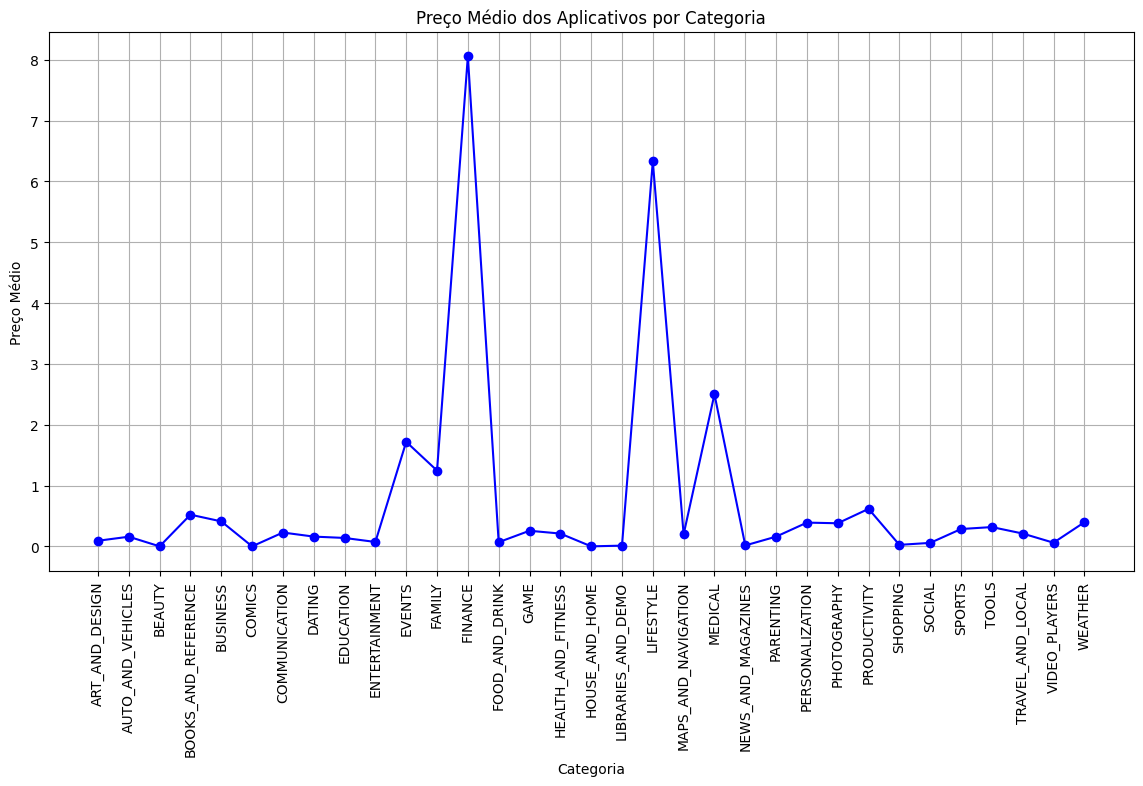

In [18]:
mdprecoCategoria = csv.groupby('Category')['Price'].mean()
print(f'Média de preço por categoria: {mdprecoCategoria}')

mp.figure(figsize=(14, 7))
mp.plot(mdprecoCategoria.index, mdprecoCategoria.values, marker='o', linestyle='-', color='b')
mp.xticks(rotation=90)
mp.xlabel('Categoria')
mp.ylabel('Preço Médio')
mp.title('Preço Médio dos Aplicativos por Categoria')
mp.grid(True)
mp.show()

## Relação entre Instalações e Reviews

Criamos um gráfico de dispersão para visualizar a relação entre o número de instalações e o número de reviews dos aplicativos.

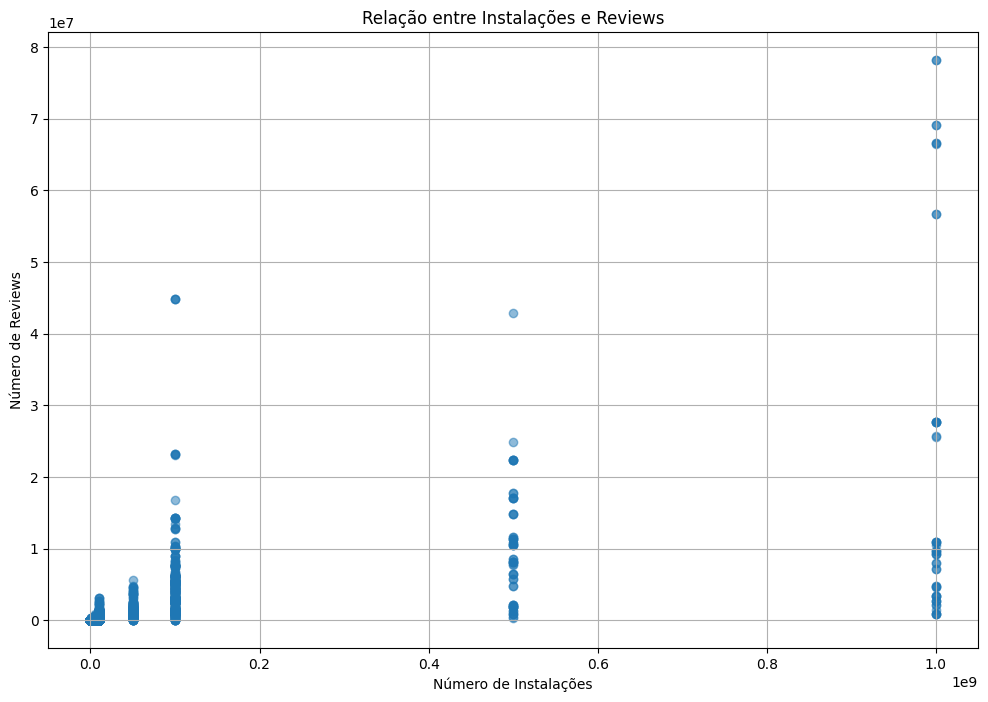

In [19]:
mp.figure(figsize=(12, 8))
mp.scatter(csv['Installs'], csv['Reviews'], alpha=0.5)
mp.xlabel('Número de Instalações')
mp.ylabel('Número de Reviews')
mp.title('Relação entre Instalações e Reviews')
mp.grid(True)
mp.show()

## App menos instalado

Aqui, identificamos o aplicativo menos instalados no dataset e exibimos seu nome e seu numero de instalação.


In [20]:
AppMenosBaixado = csv[csv['Installs'] == csv['Installs'].min()]
print(f"O aplicativo menos baixado é: {AppMenosBaixado['App'].values[0]} \nNúmero de instalações: {AppMenosBaixado['Installs'].values[0]}")

O aplicativo menos baixado é: Popsicle Launcher for Android P 9.0 launcher 
Número de instalações: 0
